In [1]:
# Cell 1 — Load and label TRAIN columns (FD001)

from pathlib import Path
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

train_path = Path("../../../CMAPSSData/train_FD001.txt")
df_train = pd.read_csv(train_path, sep=r"\s+", header=None, engine="python").dropna(axis=1, how="all")

col_names = [
    "unit", "cycle",
    "setting_1", "setting_2", "setting_3",
    *[f"s{i}" for i in range(1, 22)]
]

if df_train.shape[1] != len(col_names):
    raise ValueError(f"Unexpected #columns in train: got {df_train.shape[1]}, expected {len(col_names)}")

df_train.columns = col_names
print("Train shape:", df_train.shape)
df_train.head()

Train shape: (20631, 26)


,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [2]:
# Cell 2 — Load and label TEST columns (FD001)

from pathlib import Path
import pandas as pd

test_path = Path("../../../CMAPSSData/test_FD001.txt")
df_test = pd.read_csv(test_path, sep=r"\s+", header=None, engine="python").dropna(axis=1, how="all")

col_names = [
    "unit", "cycle",
    "setting_1", "setting_2", "setting_3",
    *[f"s{i}" for i in range(1, 22)]
]

if df_test.shape[1] != len(col_names):
    raise ValueError(f"Unexpected #columns in test: got {df_test.shape[1]}, expected {len(col_names)}")

df_test.columns = col_names
print("Test shape:", df_test.shape)
df_test.head()

Test shape: (13096, 26)


,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [3]:
# Cell 3 — Load RUL file (FD001)

from pathlib import Path
import pandas as pd

rul_path = Path("../../../CMAPSSData/RUL_FD001.txt")
df_rul = pd.read_csv(rul_path, sep=r"\s+", header=None, engine="python").dropna(axis=1, how="all")
df_rul.columns = ["RUL_at_last_cycle"]

print("RUL shape:", df_rul.shape)
df_rul.head()

RUL shape: (100, 1)


,RUL_at_last_cycle
0,112
1,98
2,69
3,82
4,91


In [4]:
# Cell 4 — Create per-row RUL labels + choose feature columns + add diffs

import numpy as np
import pandas as pd

# ---- Label TRAIN (runs to failure) ----
train_max = df_train.groupby("unit")["cycle"].max().rename("max_cycle")
df_train_labeled = df_train.merge(train_max, on="unit", how="left")
df_train_labeled["RUL"] = df_train_labeled["max_cycle"] - df_train_labeled["cycle"]
df_train_labeled = df_train_labeled.drop(columns=["max_cycle"])

# ---- Label TEST (truncated) ----
# For each test unit, true failure cycle = last_observed_cycle + RUL_at_last_cycle
test_last_cycle = df_test.groupby("unit")["cycle"].max().rename("last_cycle").reset_index()
test_last_cycle["RUL_at_last_cycle"] = df_rul["RUL_at_last_cycle"].values
test_last_cycle["failure_cycle"] = test_last_cycle["last_cycle"] + test_last_cycle["RUL_at_last_cycle"]

df_test_labeled = df_test.merge(test_last_cycle[["unit", "failure_cycle"]], on="unit", how="left")
df_test_labeled["RUL"] = df_test_labeled["failure_cycle"] - df_test_labeled["cycle"]
df_test_labeled = df_test_labeled.drop(columns=["failure_cycle"])

# --- IMPORTANT: make TEST unit IDs distinct from TRAIN to avoid leakage/overlap ---
TEST_UNIT_OFFSET = 1000
df_test_labeled["unit"] = df_test_labeled["unit"] + TEST_UNIT_OFFSET

# ---- Feature selection ----
settings_cols = ["setting_1", "setting_2", "setting_3"]
sensor_cols = [f"s{i}" for i in range(1, 22)]

INCLUDE_CYCLE_FEATURE = True
ADD_SENSOR_DIFFS = True

base_feature_cols = []
if INCLUDE_CYCLE_FEATURE:
    base_feature_cols.append("cycle")
base_feature_cols += settings_cols + sensor_cols

# ---- Add diffs (the change features) ----
if ADD_SENSOR_DIFFS:
    for _df in (df_train_labeled, df_test_labeled):
        _df.sort_values(["unit", "cycle"], inplace=True)
        for c in sensor_cols:
            _df[f"{c}_diff"] = _df.groupby("unit")[c].diff().fillna(0.0)

diff_cols = [f"{c}_diff" for c in sensor_cols] if ADD_SENSOR_DIFFS else []
feature_cols = base_feature_cols + diff_cols

print("Train labeled:", df_train_labeled.shape, "| Test labeled:", df_test_labeled.shape)
print("#features:", len(feature_cols))
df_train_labeled[["unit","cycle","RUL"] + feature_cols[:]].head()

Train labeled: (20631, 48) | Test labeled: (13096, 48)
#features: 46


,unit,cycle,RUL,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21,s1_diff,s2_diff,s3_diff,s4_diff,s5_diff,s6_diff,s7_diff,s8_diff,s9_diff,s10_diff,s11_diff,s12_diff,s13_diff,s14_diff,s15_diff,s16_diff,s17_diff,s18_diff,s19_diff,s20_diff,s21_diff
0,1,1,191,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.0000,0.0,0.0,0.0,0.0,0.00,0.0000
1,1,2,190,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,0.0,0.33,2.12,2.54,0.0,0.0,-0.61,-0.02,-2.12,0.0,0.02,0.62,0.05,-7.13,0.0123,0.0,0.0,0.0,0.0,-0.06,0.0046
2,1,3,189,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,0.0,0.20,-3.83,1.06,0.0,0.0,0.51,0.04,8.87,0.0,-0.22,0.14,-0.04,1.74,-0.0140,0.0,-2.0,0.0,0.0,-0.05,-0.0794
3,1,4,188,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,0.0,0.00,-5.20,-2.33,0.0,0.0,0.19,0.03,-3.46,0.0,-0.14,0.44,0.05,0.60,-0.0496,0.0,2.0,0.0,0.0,-0.07,0.0297
4,1,5,187,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,0.0,0.02,0.06,4.35,0.0,0.0,-0.45,-0.05,5.67,0.0,0.15,-0.67,-0.04,-0.03,0.0612,0.0,1.0,0.0,0.0,0.02,0.0305


In [5]:
# Cell 5 — Train/validation split by engine (unit)

import numpy as np
from sklearn.model_selection import GroupShuffleSplit

random_seed = 42
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_seed)

units = df_train_labeled["unit"].values
idx = np.arange(len(df_train_labeled))

train_idx, val_idx = next(gss.split(idx, groups=units))

train_units = np.unique(df_train_labeled.iloc[train_idx]["unit"].values)
val_units   = np.unique(df_train_labeled.iloc[val_idx]["unit"].values)

print("#train units:", len(train_units), "| #val units:", len(val_units))

#train units: 80 | #val units: 20


In [6]:
# Cell 6 — Tabular dataset + downsampling

import numpy as np
import pandas as pd

def downsample_by_unit(df: pd.DataFrame, stride: int) -> pd.DataFrame:
    df_sorted = df.sort_values(["unit", "cycle"]).reset_index(drop=True)
    keep = (df_sorted.groupby("unit").cumcount() % stride) == 0
    return df_sorted.loc[keep].reset_index(drop=True)

FAST_DEBUG = True

if FAST_DEBUG:
    cycle_stride = 25
    max_train_rows = 4000
    max_val_rows = 1500
else:
    cycle_stride = 5
    max_train_rows = 20000
    max_val_rows = 8000

train_tab = df_train_labeled[df_train_labeled["unit"].isin(train_units)].copy()
val_tab   = df_train_labeled[df_train_labeled["unit"].isin(val_units)].copy()

train_tab = downsample_by_unit(train_tab, cycle_stride)
val_tab   = downsample_by_unit(val_tab, cycle_stride)

if len(train_tab) > max_train_rows:
    train_tab = train_tab.sample(n=max_train_rows, random_state=random_seed)
if len(val_tab) > max_val_rows:
    val_tab = val_tab.sample(n=max_val_rows, random_state=random_seed)

print("[prep] train rows:", len(train_tab), "val rows:", len(val_tab), "stride:", cycle_stride)

[prep] train rows: 702 val rows: 173 stride: 25


In [7]:
# Cell 7 — Hierarchical Bayesian model (random intercept + OPTIONAL random slope for cycle)

import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- switches ---
TARGET_TRANSFORM = "log1p"      # "none" | "log1p"
INCLUDE_RANDOM_SLOPE = False    # True or False
LIKELIHOOD = "normal"           # keep normal for stability

# NUTS config
nuts_tune = 300 if FAST_DEBUG else 750
nuts_draws = 300 if FAST_DEBUG else 750
nuts_chains = 2
nuts_target_accept = 0.9
nuts_checks = False if FAST_DEBUG else True

# ----- Data arrays -----
X_train_raw = train_tab[feature_cols].to_numpy(float)
y_train_raw = train_tab["RUL"].to_numpy(float)
unit_train  = train_tab["unit"].to_numpy(int)

X_val_raw = val_tab[feature_cols].to_numpy(float)
y_val_raw = val_tab["RUL"].to_numpy(float)
unit_val  = val_tab["unit"].to_numpy(int)

def _y_transform(y):
    if TARGET_TRANSFORM == "none":
        return y
    if TARGET_TRANSFORM == "log1p":
        return np.log1p(np.clip(y, 0.0, None))
    raise ValueError(TARGET_TRANSFORM)

def _y_inverse(y_t):
    if TARGET_TRANSFORM == "none":
        return y_t
    if TARGET_TRANSFORM == "log1p":
        return np.expm1(y_t)
    raise ValueError(TARGET_TRANSFORM)

y_train_t = _y_transform(y_train_raw)
y_val_t   = _y_transform(y_val_raw)

# Scale X
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float64)
X_val   = scaler.transform(X_val_raw).astype(np.float64)

# Scale y in transformed space
y_mean = float(np.mean(y_train_t))
y_std  = float(np.std(y_train_t) + 1e-8)
y_train_s = ((y_train_t - y_mean) / y_std).astype(np.float64)
y_val_s   = ((y_val_t   - y_mean) / y_std).astype(np.float64)

# map training units -> index
train_units_sorted = np.sort(np.unique(unit_train))
unit_to_idx = {u:i for i,u in enumerate(train_units_sorted)}
unit_idx_train = np.array([unit_to_idx[u] for u in unit_train], dtype=int)

# helpful: cycle index in feature_cols (needed for slope variance on new units)
cycle_idx = feature_cols.index("cycle") if "cycle" in feature_cols else None
if INCLUDE_RANDOM_SLOPE and cycle_idx is None:
    raise RuntimeError("INCLUDE_RANDOM_SLOPE=True requires 'cycle' in feature_cols.")

coords = {"unit": train_units_sorted, "feature": np.array(feature_cols)}

with pm.Model(coords=coords) as model:
    X = pm.Data("X", X_train, dims=("obs","feature"))
    u = pm.Data("u", unit_idx_train, dims="obs")
    y = pm.Data("y", y_train_s, dims="obs")

    alpha = pm.Normal("alpha", 0.0, 1.0)

    # random intercept
    tau0 = pm.HalfNormal("tau0", 1.0)
    b0_offset = pm.Normal("b0_offset", 0.0, 1.0, dims="unit")
    b0 = pm.Deterministic("b0", b0_offset * tau0, dims="unit")

    # global betas
    beta = pm.Normal("beta", 0.0, 1.0, dims="feature")

    # optional random slope for cycle (engine-specific degradation rate)
    if INCLUDE_RANDOM_SLOPE:
        tau1 = pm.HalfNormal("tau1", 1.0)
        b1_offset = pm.Normal("b1_offset", 0.0, 1.0, dims="unit")
        b1 = pm.Deterministic("b1", b1_offset * tau1, dims="unit")

        cycle_x = X[:, cycle_idx]
        mu = alpha + b0[u] + pm.math.dot(X, beta) + b1[u] * cycle_x
    else:
        mu = alpha + b0[u] + pm.math.dot(X, beta)

    sigma = pm.HalfNormal("sigma", 1.0)

    nu = pm.Exponential("nu", 1/10)
    pm.StudentT("y_obs", nu=nu, mu=mu, sigma=sigma, observed=y, dims="obs")

    posterior = pm.sample(
        draws=nuts_draws, tune=nuts_tune, chains=nuts_chains, cores=1,
        target_accept=nuts_target_accept, random_seed=random_seed,
        progressbar=True, compute_convergence_checks=nuts_checks
    )

display(az.summary(posterior, var_names=["alpha","sigma","tau0"] + (["tau1"] if INCLUDE_RANDOM_SLOPE else [])))

# ---- Predict on held-out engines (new units) ----
a = posterior.posterior["alpha"].values.reshape(-1)
sigma_s = posterior.posterior["sigma"].values.reshape(-1)
tau0_s  = posterior.posterior["tau0"].values.reshape(-1)
beta_s  = posterior.posterior["beta"].values.reshape(-1, X_val.shape[1])

mu_draws_s = a[:,None] + beta_s @ X_val.T  # base mean: alpha + X beta

# predictive variance for new units:
#   var = sigma^2 + tau0^2 (+ (cycle^2)*tau1^2 if random slope)
pred_var = sigma_s[:,None]**2 + tau0_s[:,None]**2

if INCLUDE_RANDOM_SLOPE:
    tau1_s = posterior.posterior["tau1"].values.reshape(-1)
    cycle_val = X_val[:, cycle_idx][None, :]  # (1, nobs)
    pred_var = pred_var + (tau1_s[:,None]**2) * (cycle_val**2)

pred_sd = np.sqrt(pred_var)

rng = np.random.default_rng(random_seed)
y_pred_draws_s = rng.normal(loc=mu_draws_s, scale=pred_sd)

# back to raw RUL
y_pred_draws_t = y_mean + y_std * y_pred_draws_s
y_pred_draws_raw = np.clip(_y_inverse(y_pred_draws_t), 0.0, None)

pred_mean = y_pred_draws_raw.mean(axis=0)
pred_lo   = np.quantile(y_pred_draws_raw, 0.05, axis=0)
pred_hi   = np.quantile(y_pred_draws_raw, 0.95, axis=0)

rmse = float(np.sqrt(mean_squared_error(y_val_raw, pred_mean)))
mae  = float(mean_absolute_error(y_val_raw, pred_mean))
cov90 = float(np.mean((y_val_raw >= pred_lo) & (y_val_raw <= pred_hi)))

print(f"[VAL] RMSE={rmse:.3f} MAE={mae:.3f} | 90% PI coverage={cov90:.3f}")

# keep these for Cell 8
y_val = y_val_raw
y_pred_draws = y_pred_draws_raw

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, tau0, b0_offset, beta, sigma, nu]


Output()

c:\Users\lalot\anaconda3\envs\bayes_ml\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 3711 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.021,0.055,-0.102,0.103,0.016,0.011,11.0,17.0,1.20
sigma,0.089,0.006,0.079,0.098,0.000,0.000,233.0,317.0,1.02
tau0,0.376,0.033,0.322,0.441,0.008,0.003,14.0,75.0,1.12


[VAL] RMSE=41.888 MAE=28.009 | 90% PI coverage=0.902


[diag] RMSE: 41.888 | MAE: 28.009 | bias: 3.868


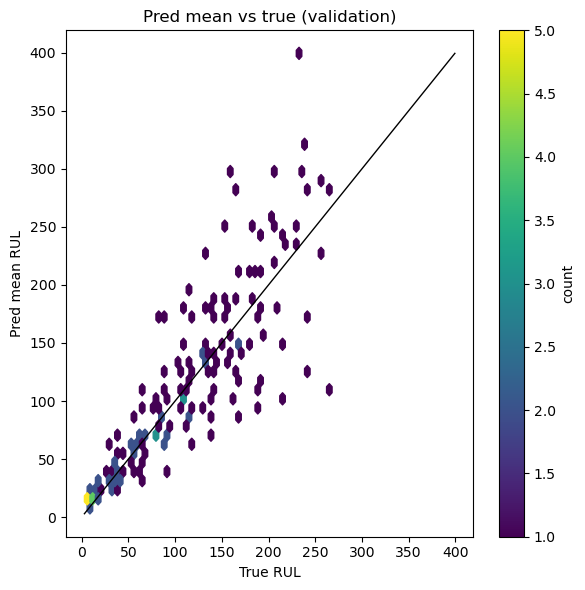

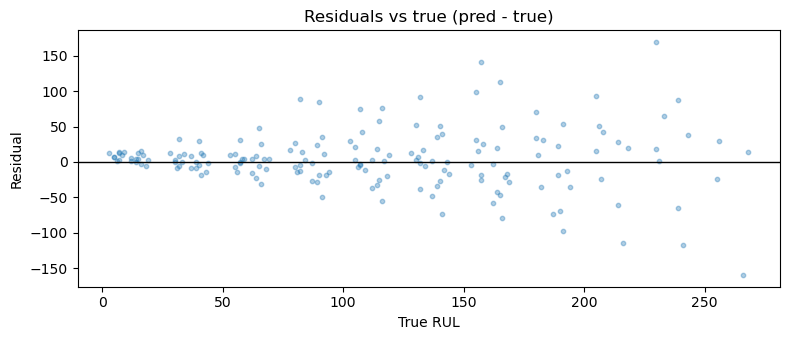

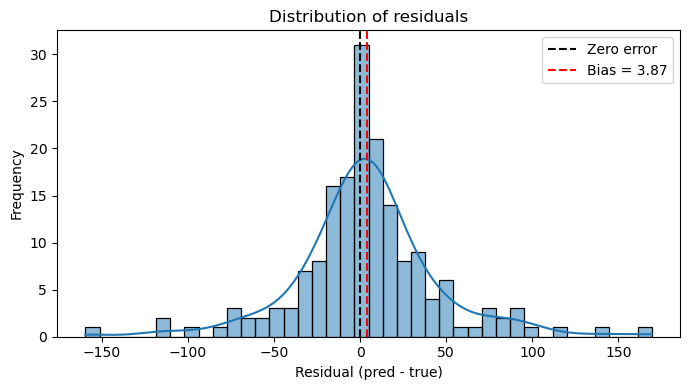


=== DEBUG START ===
len(val_units): 20
df_train_labeled units: 100
df_test_labeled exists? True
df_test_labeled units: 100
df_test_labeled RUL describe:
 count    13096.000000
mean       141.238470
std         58.980114
min          7.000000
25%        102.000000
50%        140.000000
75%        179.000000
max        340.000000
Name: RUL, dtype: float64
Any NA in df_test_labeled['RUL']? False
Unique RUL values (first 20): [ 7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26]
Units overlap (VAL ∩ TEST): 0
=== DEBUG END ===

[last-cycle/TRUEEND] RMSE=10.791 MAE=10.132 | 90% PI coverage=0.000


In [9]:
# Cell 8 — Metrics + plots (includes TRUEEND fix)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

y_true = np.asarray(y_val, float)
y_hat  = np.asarray(pred_mean, float)
draws  = np.asarray(y_pred_draws, float)

resid = y_hat - y_true
rmse = float(np.sqrt(np.mean(resid**2)))
mae  = float(np.mean(np.abs(resid)))
bias = float(np.mean(resid))

print("[diag] RMSE:", round(rmse,3), "| MAE:", round(mae,3), "| bias:", round(bias,3))

# Scatter
plt.figure(figsize=(6,6))
plt.hexbin(y_true, y_hat, gridsize=45, mincnt=1)
lo = float(min(y_true.min(), y_hat.min()))
hi = float(max(y_true.max(), y_hat.max()))
plt.plot([lo,hi],[lo,hi], color="black", linewidth=1)
plt.title("Pred mean vs true (validation)")
plt.xlabel("True RUL")
plt.ylabel("Pred mean RUL")
plt.colorbar(label="count")
plt.tight_layout()
plt.show()

# Residuals vs True
plt.figure(figsize=(8,3.5))
plt.scatter(y_true, resid, s=10, alpha=0.35)
plt.axhline(0, color="black", linewidth=1)
plt.title("Residuals vs true (pred - true)")
plt.xlabel("True RUL")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

# 🔵 NEW: Distribution of residuals
plt.figure(figsize=(7,4))
sns.histplot(resid, bins=40, kde=True)
plt.axvline(0, color="black", linestyle="--", label="Zero error")
plt.axvline(bias, color="red", linestyle="--", label=f"Bias = {bias:.2f}")
plt.title("Distribution of residuals")
plt.xlabel("Residual (pred - true)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# ---- TRUE END-OF-UNIT evaluation (FIXED) ----

print("\n=== DEBUG START ===")

print("len(val_units):", len(val_units))
print("df_train_labeled units:", df_train_labeled["unit"].nunique())

print("df_test_labeled exists?", "df_test_labeled" in globals())
if "df_test_labeled" in globals():
    print("df_test_labeled units:", df_test_labeled["unit"].nunique())
    print("df_test_labeled RUL describe:\n", df_test_labeled["RUL"].describe())
    print("Any NA in df_test_labeled['RUL']?", df_test_labeled["RUL"].isna().any())
    print("Unique RUL values (first 20):", np.sort(df_test_labeled["RUL"].unique())[:20])

if "df_test_labeled" in globals():
    val_units_set = set(val_units)
    test_units_set = set(df_test_labeled["unit"].unique())
    print("Units overlap (VAL ∩ TEST):", len(val_units_set & test_units_set))

print("=== DEBUG END ===\n")

val_full = df_train_labeled[df_train_labeled["unit"].isin(val_units)].copy()
val_last_trueend = (
    val_full.sort_values(["unit","cycle"])
    .groupby("unit", as_index=False).tail(1)
    .reset_index(drop=True)
)

X_last_raw = val_last_trueend[feature_cols].to_numpy(float)
X_last = scaler.transform(X_last_raw).astype(np.float64)

y_last_true = val_last_trueend["RUL"].to_numpy(float)

a = posterior.posterior["alpha"].values.reshape(-1)
sigma_s = posterior.posterior["sigma"].values.reshape(-1)
tau0_s  = posterior.posterior["tau0"].values.reshape(-1)
beta_s  = posterior.posterior["beta"].values.reshape(-1, X_last.shape[1])

mu_last_s = a[:,None] + beta_s @ X_last.T
pred_var_last = sigma_s[:,None]**2 + tau0_s[:,None]**2

if INCLUDE_RANDOM_SLOPE:
    tau1_s = posterior.posterior["tau1"].values.reshape(-1)
    cycle_last = X_last[:, cycle_idx][None, :]
    pred_var_last = pred_var_last + (tau1_s[:,None]**2) * (cycle_last**2)

pred_sd_last = np.sqrt(pred_var_last)

rng2 = np.random.default_rng(random_seed + 123)
y_last_draws_s = rng2.normal(loc=mu_last_s, scale=pred_sd_last)

y_last_draws_t = y_mean + y_std * y_last_draws_s
y_last_draws_raw = np.clip(_y_inverse(y_last_draws_t), 0.0, None)

pred_last_mean = y_last_draws_raw.mean(axis=0)
pred_last_lo   = np.quantile(y_last_draws_raw, 0.05, axis=0)
pred_last_hi   = np.quantile(y_last_draws_raw, 0.95, axis=0)

rmse_last = float(np.sqrt(np.mean((y_last_true - pred_last_mean)**2)))
mae_last  = float(np.mean(np.abs(y_last_true - pred_last_mean)))
cov90_last = float(np.mean((y_last_true >= pred_last_lo) & (y_last_true <= pred_last_hi)))

print(f"[last-cycle/TRUEEND] RMSE={rmse_last:.3f} MAE={mae_last:.3f} | 90% PI coverage={cov90_last:.3f}")

[diag] vars plotted: ['alpha', 'sigma', 'tau0', 'nu', 'beta']


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.021,0.055,-0.102,0.103,0.016,0.011,11.0,17.0,1.20
sigma,0.089,0.006,0.079,0.098,0.000,0.000,233.0,317.0,1.02
tau0,0.376,0.033,0.322,0.441,0.008,0.003,14.0,75.0,1.12
nu,1.710,0.173,1.373,2.014,0.011,0.009,267.0,295.0,1.02


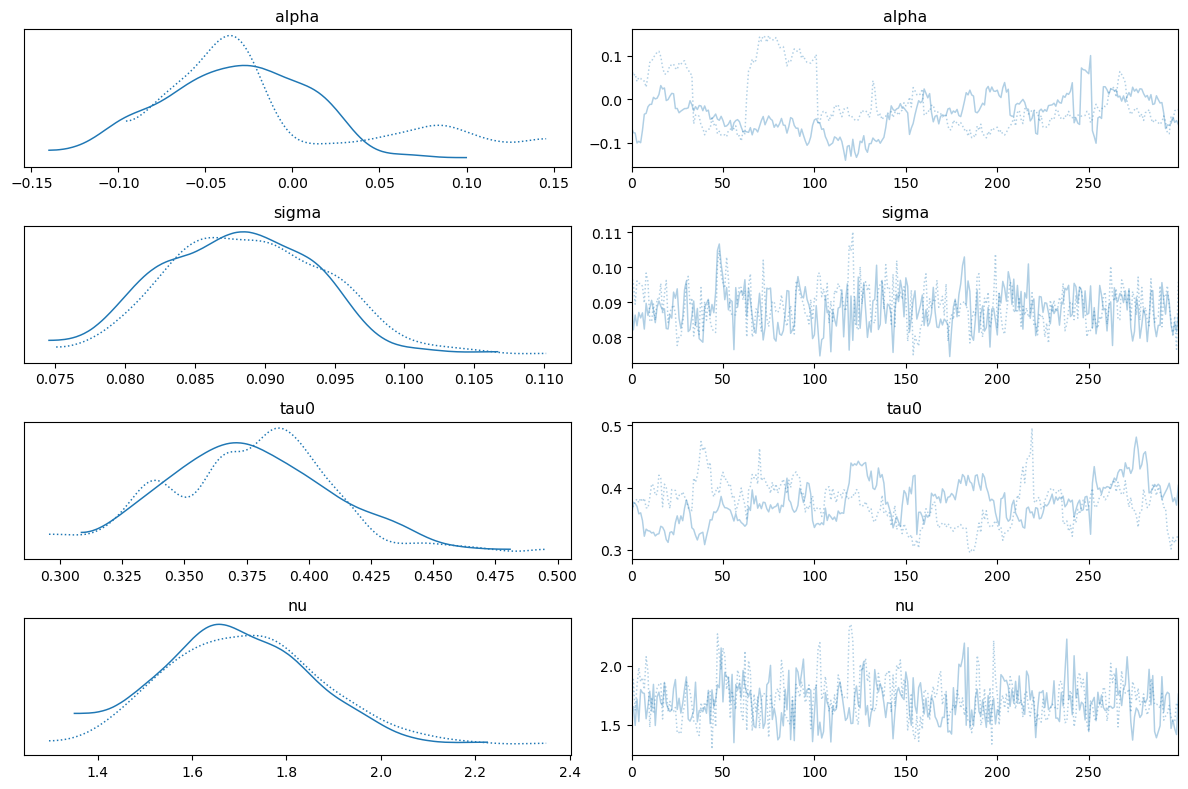

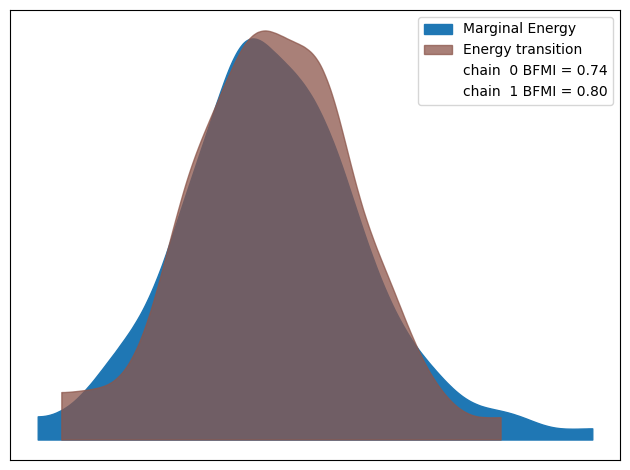

[diag] divergences: 0


In [17]:
# Cell 9 — Convergence / fit diagnostics (ArviZ)
# Produces trace plots like your screenshot (solid vs dotted per chain) + energy plot (blue/brown)

import arviz as az
import matplotlib.pyplot as plt

if "posterior" not in globals():
    raise RuntimeError("`posterior` not found. Run the model (Cell 7) first.")

# Pick variables that exist in your posterior
cand = ["alpha", "sigma", "tau0", "tau1", "nu", "beta"]
key_vars = [v for v in cand if v in posterior.posterior.data_vars]

print("[diag] vars plotted:", key_vars)

# Summary table (Rhat, ESS, etc.)
try:
    display(az.summary(posterior, var_names=[v for v in key_vars if v != "beta"]))
except Exception as e:
    print("az.summary failed:", e)

# Trace plots (this is what gives dotted vs solid lines by chain)
az.plot_trace(
    posterior,
    var_names=[v for v in key_vars if v != "beta"],  # beta is huge; keep it out unless you want it
    compact=True
)
plt.tight_layout()
plt.show()

# Energy plot (blue + brown overlay)
try:
    az.plot_energy(posterior)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Energy plot skipped:", e)

# Extra: report divergences (useful for your write-up)
try:
    divs = int(posterior.sample_stats["diverging"].values.sum())
    print("[diag] divergences:", divs)
except Exception as e:
    print("Could not read divergences:", e)

In [18]:
# Cell 10 — Export CSV with (RUL_true, RUL_pred_mean, error) for TRAIN and TEST

import numpy as np
import pandas as pd

if "posterior" not in globals():
    raise RuntimeError("`posterior` not found. Run the model cell first.")
if "scaler" not in globals() or "feature_cols" not in globals():
    raise RuntimeError("Missing `scaler` or `feature_cols`. Run Cell 4 + preprocessing first.")
if "df_train_labeled" not in globals() or "df_test_labeled" not in globals():
    raise RuntimeError("Missing df_train_labeled / df_test_labeled. Run Cell 4 first.")
if "y_mean" not in globals() or "y_std" not in globals() or "_y_inverse" not in globals():
    raise RuntimeError("Missing y_mean/y_std/_y_inverse. Run Cell 6/7 first.")

random_seed = globals().get("random_seed", 123)

def predict_df(df_in: pd.DataFrame, name: str) -> pd.DataFrame:
    df = df_in.copy()

    # Build X
    X_raw = df[feature_cols].to_numpy(float)
    X = scaler.transform(X_raw).astype(np.float64)

    # True RUL
    y_true = df["RUL"].to_numpy(float)

    # Pull posterior draws
    a = posterior.posterior["alpha"].values.reshape(-1)
    sigma_s = posterior.posterior["sigma"].values.reshape(-1)
    tau0_s  = posterior.posterior["tau0"].values.reshape(-1)
    beta_s  = posterior.posterior["beta"].values.reshape(-1, X.shape[1])

    # Mean (standardized space)
    mu_s = a[:, None] + beta_s @ X.T

    # Variance (marginalize random intercept; and random slope if enabled)
    pred_var = sigma_s[:, None]**2 + tau0_s[:, None]**2

    if globals().get("INCLUDE_RANDOM_SLOPE", False):
        if "tau1" in posterior.posterior:
            tau1_s = posterior.posterior["tau1"].values.reshape(-1)
            cycle_idx = globals().get("cycle_idx", None)
            if cycle_idx is None:
                raise RuntimeError("INCLUDE_RANDOM_SLOPE=True but `cycle_idx` not found.")
            cycle_x = X[:, cycle_idx][None, :]
            pred_var = pred_var + (tau1_s[:, None]**2) * (cycle_x**2)

    pred_sd = np.sqrt(pred_var)

    # Sample predictive draws (standardized space)
    rng = np.random.default_rng(random_seed + (0 if name == "train" else 999))
    y_draws_s = rng.normal(loc=mu_s, scale=pred_sd)

    # Back-transform to raw RUL
    y_draws_t = y_mean + y_std * y_draws_s
    y_draws_raw = np.clip(_y_inverse(y_draws_t), 0.0, None)

    pred_mean = y_draws_raw.mean(axis=0)
    pred_p05  = np.quantile(y_draws_raw, 0.05, axis=0)
    pred_p95  = np.quantile(y_draws_raw, 0.95, axis=0)

    err = pred_mean - y_true

    out = pd.DataFrame({
        "split": name,
        "unit": df["unit"].to_numpy(int),
        "cycle": df["cycle"].to_numpy(int),
        "RUL_true": y_true,
        "RUL_pred_mean": pred_mean,
        "error": err,
        "abs_error": np.abs(err),
        "pred_p05": pred_p05,
        "pred_p95": pred_p95,
    })

    return out

train_out = predict_df(df_train_labeled, "train")
test_out  = predict_df(df_test_labeled, "test")

train_csv = "train_rul_predictions.csv"
test_csv  = "test_rul_predictions.csv"

train_out.to_csv(train_csv, index=False)
test_out.to_csv(test_csv, index=False)

print("Saved:", train_csv, "| rows:", len(train_out))
print("Saved:", test_csv,  "| rows:", len(test_out))

# Quick sanity metrics (optional)
for name, dfp in [("TRAIN", train_out), ("TEST", test_out)]:
    rmse = float(np.sqrt(np.mean(dfp["error"].values**2)))
    mae  = float(np.mean(np.abs(dfp["error"].values)))
    bias = float(np.mean(dfp["error"].values))
    print(f"[{name}] RMSE={rmse:.3f} | MAE={mae:.3f} | bias={bias:.3f}")

Saved: train_rul_predictions.csv | rows: 20631
Saved: test_rul_predictions.csv | rows: 13096
[TRAIN] RMSE=47.368 | MAE=33.704 | bias=2.398
[TEST] RMSE=55.565 | MAE=42.379 | bias=6.883
